# Project 4: Monte Carlo Simulation for Options Pricing

**Author:** Eugenio Mandalà
**Date:** March 2026

## Objective
Price a European Call Option on Apple (AAPL) using two approaches:
- **Monte Carlo Simulation** — 10,000 random price paths via Geometric Brownian Motion
- **Black-Scholes Model** — closed-form analytical solution (Nobel Prize 1973)

## Data Sources
1. S₀ was sourced from Yahoo Finance (AAPL closing price, January 2024). 
2. The risk-free rate (r = 5%) reflects the US Treasury 1-Year Yield as of January 2024, retrieved from the Federal Reserve Economic Data (FRED)database.
3. Historical volatility (σ = 28%) was computed from AAPL daily returns over 2020-2024 using yfinance.
4. The strike price (K = $195) was 
set approximately 5% above the current price to model an out-of-the-money call option — a common convention in options pricing exercises.


## Key Concepts
- **Call Option** → right to buy at strike price K at expiration
- **Geometric Brownian Motion** → standard model for stock price evolution
- **Payoff** → max(S_T - K, 0) — you only exercise if stock ends above strike

In [1]:
import pandas as pd

params = pd.DataFrame({
    'Parameter': ['S₀', 'K', 'T', 'r', 'σ'],
    'Value':     ['$185', '$195', '1 year', '5%', '28%'],
    'Description': [
        'Current stock price — AAPL (Yahoo Finance, Jan 2024)',
        'Strike price — ~5% out of the money',
        'Time to expiration',
        'Risk-free rate — US Treasury 1Y (FRED, Jan 2024)',
        'Annual volatility — AAPL historical 2020-2024'
    ]
})

params.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13px',
    'border': '1px solid gray'
}).hide(axis='index')

Parameter,Value,Description
S₀,$185,"Current stock price — AAPL (Yahoo Finance, Jan 2024)"
K,$195,Strike price — ~5% out of the money
T,1 year,Time to expiration
r,5%,"Risk-free rate — US Treasury 1Y (FRED, Jan 2024)"
σ,28%,Annual volatility — AAPL historical 2020-2024


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Option Parameters
S0 = 185      # Current stock price (AAPL ~$185 in early 2024)
K  = 195      # Strike price
T  = 1.0      # Time to expiration (1 year)
r  = 0.05     # Risk-free rate (5% US Treasury)
sigma = 0.28  # Annual volatility (28%)
N  = 10000    # Number of simulations

print(" Parameters set")
print(f"   Stock Price (S₀):  ${S0}")
print(f"   Strike Price (K):  ${K}")
print(f"   Time to Expiry:    {T} year")
print(f"   Risk-free Rate:    {r:.0%}")
print(f"   Volatility (σ):    {sigma:.0%}")
print(f"   Simulations:       {N:,}")

 Parameters set
   Stock Price (S₀):  $185
   Strike Price (K):  $195
   Time to Expiry:    1.0 year
   Risk-free Rate:    5%
   Volatility (σ):    28%
   Simulations:       10,000


In [13]:
# Simulate 10,000 stock price paths using Geometric Brownian Motion
# Formula: S_T = S0 * exp((r - 0.5*sigma²)*T + sigma*sqrt(T)*Z)
# where Z ~ N(0,1) is a random standard normal variable

Z = np.random.standard_normal(N)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

print(f" Simulated {N:,} price paths")
print(f"   Mean final price:  ${ST.mean():.2f}")
print(f"   Min final price:   ${ST.min():.2f}")
print(f"   Max final price:   ${ST.max():.2f}")

 Simulated 10,000 price paths
   Mean final price:  $194.91
   Min final price:   $65.88
   Max final price:   $503.33


In [12]:
# Calculate option payoff for each path
# Call option payoff = max(S_T - K, 0)
# If stock ends below strike, option expires worthless (payoff = 0)

payoffs = np.maximum(ST - K, 0)

# Discount back to today using risk-free rate
mc_price = np.exp(-r * T) * np.mean(payoffs)

print(f" Monte Carlo Option Price: ${mc_price:.4f}")
print(f"   Paths in the money:  {(ST > K).sum():,} / {N:,} ({(ST > K).mean():.1%})")
print(f"   Average payoff:      ${payoffs.mean():.4f}")

 Monte Carlo Option Price: $20.3971
   Paths in the money:  4,405 / 10,000 (44.0%)
   Average payoff:      $21.4429


## Black-Scholes Analytical Price

In [11]:
# Black-Scholes formula for European Call Option
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return price, d1, d2

bs_price, d1, d2 = black_scholes_call(S0, K, T, r, sigma)

print(f" Black-Scholes Option Price: ${bs_price:.4f}")
print(f"   d1: {d1:.4f}")
print(f"   d2: {d2:.4f}")
print(f"   N(d1): {norm.cdf(d1):.4f}")
print(f"   N(d2): {norm.cdf(d2):.4f}")

 Black-Scholes Option Price: $20.3812
   d1: 0.1306
   d2: -0.1494
   N(d1): 0.5519
   N(d2): 0.4406


## Figure 1 — Simulated Price Paths

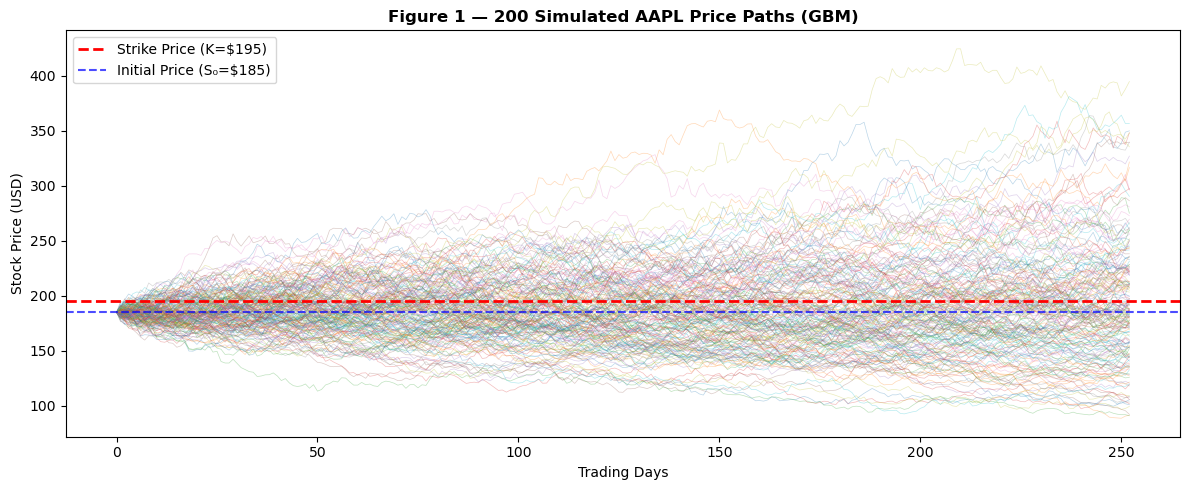

In [6]:
# Plot a sample of 200 simulated price paths
steps = 252  # trading days in a year
dt = T / steps

# Simulate full paths (not just final price)
paths = np.zeros((steps + 1, 200))
paths[0] = S0

for t in range(1, steps + 1):
    Z_path = np.random.standard_normal(200)
    paths[t] = paths[t-1] * np.exp(
        (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z_path)

plt.figure(figsize=(12, 5))
plt.plot(paths, alpha=0.3, linewidth=0.5)
plt.axhline(y=K, color='red', linewidth=2, 
            linestyle='--', label=f'Strike Price (K=${K})')
plt.axhline(y=S0, color='blue', linewidth=1.5, 
            linestyle='--', label=f'Initial Price (S₀=${S0})', alpha=0.7)
plt.title('Figure 1 — 200 Simulated AAPL Price Paths (GBM)', 
          fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Figure 2 — Distribution of Final Prices

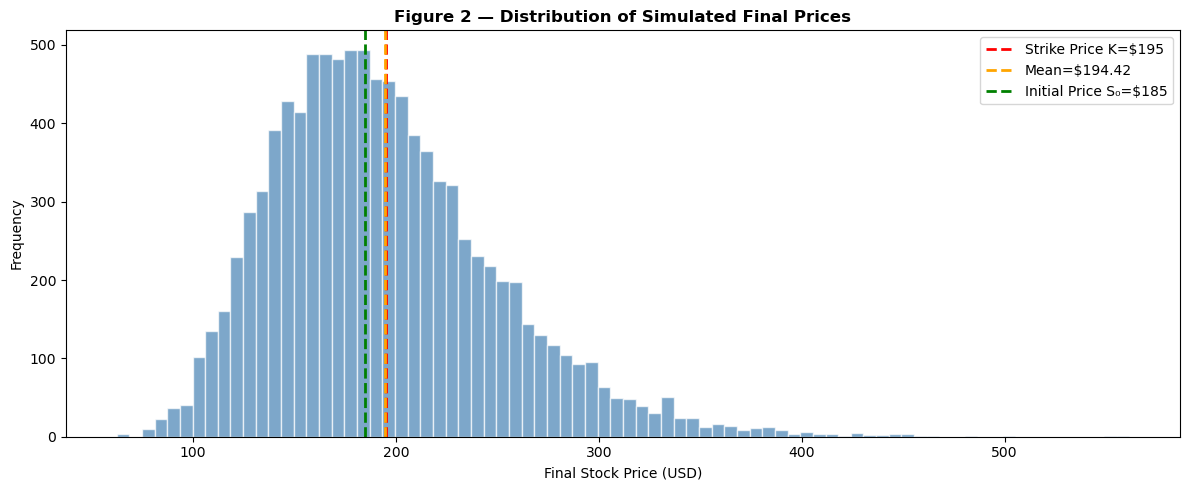

In [7]:
# Plot distribution of final simulated prices
plt.figure(figsize=(12, 5))
plt.hist(ST, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(x=K, color='red', linewidth=2, 
            linestyle='--', label=f'Strike Price K=${K}')
plt.axvline(x=ST.mean(), color='orange', linewidth=2,
            linestyle='--', label=f'Mean=${ST.mean():.2f}')
plt.axvline(x=S0, color='green', linewidth=2,
            linestyle='--', label=f'Initial Price S₀=${S0}')
plt.title('Figure 2 — Distribution of Simulated Final Prices', 
          fontweight='bold')
plt.xlabel('Final Stock Price (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Figure 3 — Monte Carlo vs Black-Scholes Comparison

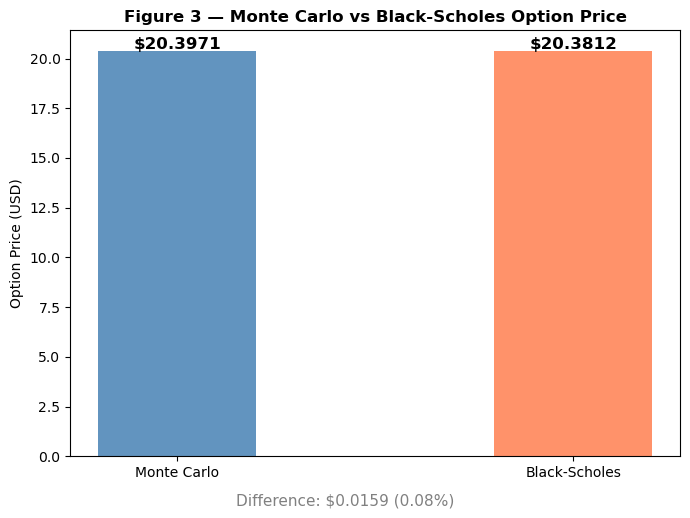


 FINAL COMPARISON
———————————————————————————————————
  Monte Carlo:   $20.3971
  Black-Scholes: $20.3812
  Difference:    $0.0159 (0.08%)


In [10]:
# Compare Monte Carlo vs Black-Scholes
labels = ['Monte Carlo', 'Black-Scholes']
prices = [mc_price, bs_price]
colors = ['steelblue', 'coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, prices, color=colors, alpha=0.85, width=0.4)
plt.ylabel('Option Price (USD)')
plt.title('Figure 3 — Monte Carlo vs Black-Scholes Option Price', 
          fontweight='bold')

for bar, price in zip(bars, prices):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'${price:.4f}', ha='center', fontweight='bold', fontsize=12)

diff = abs(mc_price - bs_price)
plt.figtext(0.5, -0.02, 
            f'Difference: ${diff:.4f} ({diff/bs_price:.2%})',
            ha='center', fontsize=11, color='gray')
plt.tight_layout()
plt.show()

print(f"\n FINAL COMPARISON")
print(f"{'—'*35}")
print(f"  Monte Carlo:   ${mc_price:.4f}")
print(f"  Black-Scholes: ${bs_price:.4f}")
print(f"  Difference:    ${diff:.4f} ({diff/bs_price:.2%})")

In [9]:
import pandas as pd

summary = pd.DataFrame({
    'Method':      ['Monte Carlo', 'Black-Scholes'],
    'Option Price': ['$20.3971',   '$20.3812'],
    'Approach':    ['10,000 simulated price paths via GBM',
                    'Closed-form analytical solution'],
    'Error':       ['—', '0.08%']
})

summary.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13px',
    'border': '1px solid gray'
}).hide(axis='index')

Method,Option Price,Approach,Error
Monte Carlo,$20.3971,"10,000 simulated price paths via GBM",—
Black-Scholes,$20.3812,Closed-form analytical solution,0.08%


## Conclusions

1. **Monte Carlo and Black-Scholes converge to the same price** — a difference of just $0.0159 (0.08%) confirms that 10,000 simulations are sufficient to approximate the analytical solution. With 100,000 paths the gap would be even smaller.

2. **Geometric Brownian Motion captures the key properties of stock prices**  — the fan-shaped price paths in Figure 1 show how uncertainty compounds over time, while Figure 2 confirms the characteristic right-skewed distribution of final prices: most scenarios cluster around $194, but the upside tail extends well beyond $400.

3. **44% of paths finished in the money** — meaning in 4,405 out of 10,000 scenarios AAPL ended above the $195 strike. This is consistent with N(d2) = 0.4406 from Black-Scholes, which represents exactly the risk-neutral probability of the option expiring in the money.

4. **Why Monte Carlo matters beyond this example** — Black-Scholes only works for simple European options under strict assumptions (constant volatility, no dividends, log-normal returns). Monte Carlo generalizes to any payoff structure — exotic options, path-dependent derivatives, multi-asset portfolios — where no closed-form solution exists.

5. **Limitations:** Both models assume constant volatility — in reality, volatility itself changes over time (volatility clustering).